# Variant-level Analysis — Which UI Variant Should We Roll Out?

## Goal
In `02_ab_experiment`, we found that **non-default UI (any variant)** is associated with higher high-intent conversion and lower bounce rate.

This notebook drills down to the **variant level** to answer:

> Which specific UI variants outperform the default UI, and are the results robust?

We will:
- Rank variants by conversion rate (with minimum sample threshold)
- Compare each variant vs default using two-proportion z-tests
- Report effect size + 95% CI
- Adjust for multiple comparisons (Benjamini–Hochberg FDR)
- Run lightweight robustness checks on higher-quality sessions


In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)


## Data Input

This notebook expects the `session` table created in `01_eda.ipynb` and used in `02_ab_experiment.ipynb`.

Required columns:
- `group_mode` (str): UI variant group label (e.g., "default", "230401_..._lottery", hash-like ids)
- `converted_hi` (0/1): high-intent conversion proxy
- `is_bounce` (0/1): bounce proxy
- `n_events`, `session_duration_sec` (optional but recommended)


In [20]:

session = pd.read_parquet("../data/session_level.parquet")

session.shape, session["group_mode"].nunique(), session["converted_hi"].mean()


((100357, 10), 15, np.float64(0.04838725749075799))

## Variant Coverage & Minimum Sample Threshold

Many UI variants may have small sample sizes. To avoid ranking noise, we:
- compute per-variant metrics
- filter to variants with `n_sessions >= MIN_N`
- keep `default` regardless (as baseline)


In [21]:
MIN_N = 200

variant_summary = (
    session.groupby("group_mode")
    .agg(
        n_sessions=("converted_hi", "size"),
        conv_rate=("converted_hi", "mean"),
        bounce_rate=("is_bounce", "mean"),
        avg_events=("n_events", "mean"),
        avg_duration_sec=("session_duration_sec", "mean") if "session_duration_sec" in session.columns else ("converted_hi","size"),
    )
    .reset_index()
)

# fix if duration not present
if "session_duration_sec" not in session.columns:
    variant_summary["avg_duration_sec"] = np.nan

variant_summary = variant_summary.sort_values("n_sessions", ascending=False)
variant_summary.head(10)


,group_mode,n_sessions,conv_rate,bounce_rate,avg_events,avg_duration_sec
12,default,91866,0.045577,0.619587,1.945268,197.747883
9,230401_230612_1686725101__lottery_default,1609,0.072094,0.457427,2.586700,397.350528
8,230401_230612_1686725101__lottery,1527,0.071382,0.474132,2.547479,372.474132
2,230401_230612_1686725101__2,968,0.063017,0.523760,2.216942,300.216942
3,230401_230612_1686725101__2_default,886,0.064334,0.541761,2.234763,319.108352
11,8783cca2582243602a52eee552472f0856f35ff55c49ca...,635,0.130709,0.398425,3.193701,555.798425
6,230401_230612_1686725101__4,496,0.084677,0.487903,2.427419,377.776210
7,230401_230612_1686725101__4_default,437,0.070938,0.503432,2.443936,373.077803
4,230401_230612_1686725101__3,436,0.098624,0.538991,2.238532,362.477064
5,230401_230612_1686725101__3_default,413,0.067797,0.503632,2.433414,351.138015


In [22]:
variants_keep = variant_summary.loc[
    (variant_summary["n_sessions"] >= MIN_N) | (variant_summary["group_mode"] == "default"),
    "group_mode"
].tolist()

stable_variants = variant_summary[variant_summary["group_mode"].isin(variants_keep)].copy()
stable_variants = stable_variants.sort_values("conv_rate", ascending=False)

stable_variants.head(15)


,group_mode,n_sessions,conv_rate,bounce_rate,avg_events,avg_duration_sec
11,8783cca2582243602a52eee552472f0856f35ff55c49ca...,635,0.130709,0.398425,3.193701,555.798425
13,f13213565627e05fcf069a678d30f13ba72c73297b5ca0...,291,0.113402,0.481100,3.192440,483.054983
4,230401_230612_1686725101__3,436,0.098624,0.538991,2.238532,362.477064
6,230401_230612_1686725101__4,496,0.084677,0.487903,2.427419,377.776210
9,230401_230612_1686725101__lottery_default,1609,0.072094,0.457427,2.586700,397.350528
8,230401_230612_1686725101__lottery,1527,0.071382,0.474132,2.547479,372.474132
7,230401_230612_1686725101__4_default,437,0.070938,0.503432,2.443936,373.077803
5,230401_230612_1686725101__3_default,413,0.067797,0.503632,2.433414,351.138015
3,230401_230612_1686725101__2_default,886,0.064334,0.541761,2.234763,319.108352
2,230401_230612_1686725101__2,968,0.063017,0.523760,2.216942,300.216942


## Top Variants by Conversion (Filtered)

This chart shows conversion rates for variants with sufficient sample size (>= MIN_N).


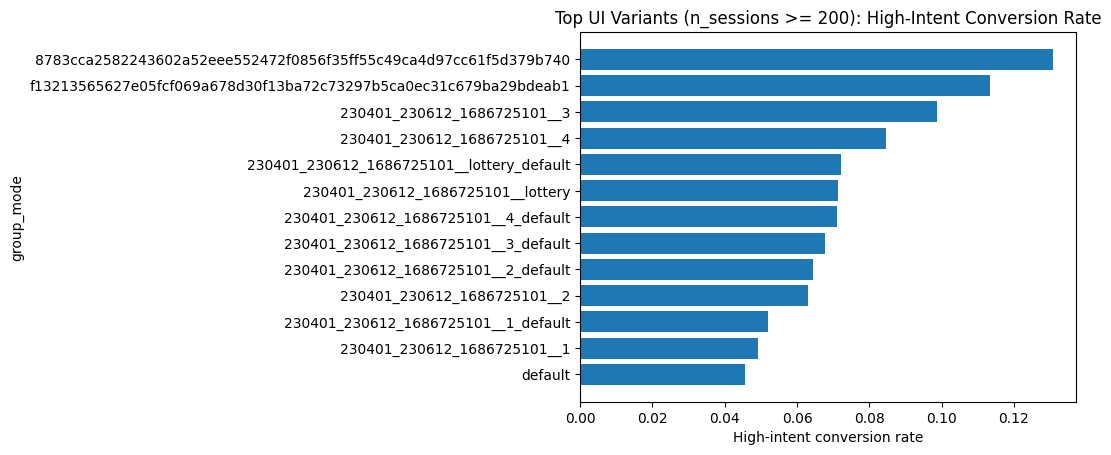

In [23]:
top_k = 15
plot_df = stable_variants.head(top_k).sort_values("conv_rate")

plt.figure()
plt.barh(plot_df["group_mode"], plot_df["conv_rate"])
plt.title(f"Top UI Variants (n_sessions >= {MIN_N}): High-Intent Conversion Rate")
plt.xlabel("High-intent conversion rate")
plt.ylabel("group_mode")
plt.show()


## Variant vs Default: Statistical Comparison

For each stable variant, we compare its conversion rate against **default**:
- Two-proportion z-test
- Absolute lift (pp) and Relative lift (%)
- 95% CI for absolute lift

We then apply **multiple-comparison correction** using Benjamini–Hochberg (FDR),
since testing many variants inflates false positives.


In [24]:
def two_prop_test(x_t, n_t, x_c, n_c):
    """Two-proportion z-test (two-sided) with numerically stable p-value."""
    p_t = x_t / n_t
    p_c = x_c / n_c

    # pooled SE under H0
    p_pool = (x_t + x_c) / (n_t + n_c)
    se_pool = np.sqrt(p_pool * (1 - p_pool) * (1/n_t + 1/n_c))
    z = (p_t - p_c) / se_pool
    p_value = 2 * stats.norm.sf(abs(z))  # stable

    # unpooled CI for difference
    se_diff = np.sqrt(p_t*(1-p_t)/n_t + p_c*(1-p_c)/n_c)
    lift_abs = p_t - p_c
    ci_low = lift_abs - 1.96 * se_diff
    ci_high = lift_abs + 1.96 * se_diff

    lift_rel = lift_abs / p_c if p_c > 0 else np.nan

    return {
        "p_control": p_c,
        "p_treat": p_t,
        "abs_lift": lift_abs,
        "rel_lift": lift_rel,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "z": z,
        "p_value": p_value,
    }


def benjamini_hochberg(pvals: pd.Series) -> pd.Series:
    """Benjamini-Hochberg FDR adjusted p-values."""
    p = pvals.values
    n = len(p)
    order = np.argsort(p)
    ranked = p[order]
    adj = np.empty(n, dtype=float)

    # BH: p_adj(i) = min_{j>=i} (n/j) * p(j)
    prev = 1.0
    for i in range(n-1, -1, -1):
        rank = i + 1
        val = ranked[i] * n / rank
        prev = min(prev, val)
        adj[i] = prev

    out = np.empty(n, dtype=float)
    out[order] = np.clip(adj, 0, 1)
    return pd.Series(out, index=pvals.index)


In [25]:
default_df = session[session["group_mode"] == "default"]
n_c = default_df.shape[0]
x_c = int(default_df["converted_hi"].sum())

rows = []
for g in stable_variants["group_mode"]:
    if g == "default":
        continue
    df_g = session[session["group_mode"] == g]
    n_t = df_g.shape[0]
    x_t = int(df_g["converted_hi"].sum())

    res = two_prop_test(x_t=x_t, n_t=n_t, x_c=x_c, n_c=n_c)
    rows.append({
        "group_mode": g,
        "n_treat": n_t,
        "conv_treat": x_t / n_t,
        "conv_control": x_c / n_c,
        "abs_lift": res["abs_lift"],
        "rel_lift": res["rel_lift"],
        "ci_low": res["ci_low"],
        "ci_high": res["ci_high"],
        "z": res["z"],
        "p_value": res["p_value"],
        "bounce_treat": df_g["is_bounce"].mean(),
        "bounce_control": default_df["is_bounce"].mean(),
    })

tests = pd.DataFrame(rows).sort_values("abs_lift", ascending=False).reset_index(drop=True)
tests.head(10)


,group_mode,n_treat,conv_treat,conv_control,abs_lift,rel_lift,ci_low,ci_high,z,p_value,bounce_treat,bounce_control
0,8783cca2582243602a52eee552472f0856f35ff55c49ca...,635,0.130709,0.045577,0.085131,1.867849,0.058878,0.111384,10.188324,2.235850e-24,0.398425,0.619587
1,f13213565627e05fcf069a678d30f13ba72c73297b5ca0...,291,0.113402,0.045577,0.067825,1.488128,0.031368,0.104282,5.526302,3.270516e-08,0.481100,0.619587
2,230401_230612_1686725101__3,436,0.098624,0.045577,0.053047,1.163883,0.025027,0.081066,5.284387,1.261262e-07,0.538991,0.619587
3,230401_230612_1686725101__4,496,0.084677,0.045577,0.039100,0.857888,0.014562,0.063638,4.154850,3.255006e-05,0.487903,0.619587
4,230401_230612_1686725101__lottery_default,1609,0.072094,0.045577,0.026517,0.581808,0.013807,0.039227,5.031890,4.856678e-07,0.457427,0.619587
5,230401_230612_1686725101__lottery,1527,0.071382,0.045577,0.025805,0.566171,0.012821,0.038788,4.774045,1.805617e-06,0.474132,0.619587
6,230401_230612_1686725101__4_default,437,0.070938,0.045577,0.025361,0.556439,0.001253,0.049469,2.532722,1.131808e-02,0.503432,0.619587
7,230401_230612_1686725101__3_default,413,0.067797,0.045577,0.022219,0.487510,-0.002064,0.046503,2.157930,3.093328e-02,0.503632,0.619587
8,230401_230612_1686725101__2_default,886,0.064334,0.045577,0.018757,0.411539,0.002545,0.034969,2.659111,7.834718e-03,0.541761,0.619587
9,230401_230612_1686725101__2,968,0.063017,0.045577,0.017439,0.382631,0.002072,0.032806,2.582987,9.794898e-03,0.523760,0.619587


In [26]:
tests["p_adj_fdr"] = benjamini_hochberg(tests["p_value"])
tests["sig_fdr_0.05"] = tests["p_adj_fdr"] < 0.05

tests.sort_values(["sig_fdr_0.05", "abs_lift"], ascending=[False, False]).head(15)


,group_mode,n_treat,conv_treat,conv_control,abs_lift,rel_lift,ci_low,ci_high,z,p_value,bounce_treat,bounce_control,p_adj_fdr,sig_fdr_0.05
0,8783cca2582243602a52eee552472f0856f35ff55c49ca...,635,0.130709,0.045577,0.085131,1.867849,0.058878,0.111384,10.188324,2.235850e-24,0.398425,0.619587,2.683020e-23,True
1,f13213565627e05fcf069a678d30f13ba72c73297b5ca0...,291,0.113402,0.045577,0.067825,1.488128,0.031368,0.104282,5.526302,3.270516e-08,0.481100,0.619587,1.962310e-07,True
2,230401_230612_1686725101__3,436,0.098624,0.045577,0.053047,1.163883,0.025027,0.081066,5.284387,1.261262e-07,0.538991,0.619587,5.045047e-07,True
3,230401_230612_1686725101__4,496,0.084677,0.045577,0.039100,0.857888,0.014562,0.063638,4.154850,3.255006e-05,0.487903,0.619587,6.510011e-05,True
4,230401_230612_1686725101__lottery_default,1609,0.072094,0.045577,0.026517,0.581808,0.013807,0.039227,5.031890,4.856678e-07,0.457427,0.619587,1.457003e-06,True
5,230401_230612_1686725101__lottery,1527,0.071382,0.045577,0.025805,0.566171,0.012821,0.038788,4.774045,1.805617e-06,0.474132,0.619587,4.333481e-06,True
6,230401_230612_1686725101__4_default,437,0.070938,0.045577,0.025361,0.556439,0.001253,0.049469,2.532722,1.131808e-02,0.503432,0.619587,1.509077e-02,True
7,230401_230612_1686725101__3_default,413,0.067797,0.045577,0.022219,0.487510,-0.002064,0.046503,2.157930,3.093328e-02,0.503632,0.619587,3.711993e-02,True
8,230401_230612_1686725101__2_default,886,0.064334,0.045577,0.018757,0.411539,0.002545,0.034969,2.659111,7.834718e-03,0.541761,0.619587,1.343095e-02,True
9,230401_230612_1686725101__2,968,0.063017,0.045577,0.017439,0.382631,0.002072,0.032806,2.582987,9.794898e-03,0.523760,0.619587,1.469235e-02,True


## Results Table (Variant vs Default)

Key columns:
- `abs_lift`: absolute conversion lift vs default
- `ci_low`, `ci_high`: 95% CI for the lift
- `p_value`: raw p-value
- `p_adj_fdr`: FDR-adjusted p-value
- `sig_fdr_0.05`: whether significant after correction

We prioritize variants that:
1) have large positive lift with CI above 0
2) remain significant after FDR correction
3) do not worsen bounce rate (guardrail)


In [27]:
report_cols = [
    "group_mode", "n_treat",
    "conv_treat", "conv_control",
    "abs_lift", "ci_low", "ci_high",
    "rel_lift", "p_value", "p_adj_fdr", "sig_fdr_0.05",
    "bounce_treat", "bounce_control",
]

tests.sort_values(["sig_fdr_0.05", "abs_lift"], ascending=[False, False])[report_cols].head(20)


,group_mode,n_treat,conv_treat,conv_control,abs_lift,ci_low,ci_high,rel_lift,p_value,p_adj_fdr,sig_fdr_0.05,bounce_treat,bounce_control
0,8783cca2582243602a52eee552472f0856f35ff55c49ca...,635,0.130709,0.045577,0.085131,0.058878,0.111384,1.867849,2.235850e-24,2.683020e-23,True,0.398425,0.619587
1,f13213565627e05fcf069a678d30f13ba72c73297b5ca0...,291,0.113402,0.045577,0.067825,0.031368,0.104282,1.488128,3.270516e-08,1.962310e-07,True,0.481100,0.619587
2,230401_230612_1686725101__3,436,0.098624,0.045577,0.053047,0.025027,0.081066,1.163883,1.261262e-07,5.045047e-07,True,0.538991,0.619587
3,230401_230612_1686725101__4,496,0.084677,0.045577,0.039100,0.014562,0.063638,0.857888,3.255006e-05,6.510011e-05,True,0.487903,0.619587
4,230401_230612_1686725101__lottery_default,1609,0.072094,0.045577,0.026517,0.013807,0.039227,0.581808,4.856678e-07,1.457003e-06,True,0.457427,0.619587
5,230401_230612_1686725101__lottery,1527,0.071382,0.045577,0.025805,0.012821,0.038788,0.566171,1.805617e-06,4.333481e-06,True,0.474132,0.619587
6,230401_230612_1686725101__4_default,437,0.070938,0.045577,0.025361,0.001253,0.049469,0.556439,1.131808e-02,1.509077e-02,True,0.503432,0.619587
7,230401_230612_1686725101__3_default,413,0.067797,0.045577,0.022219,-0.002064,0.046503,0.487510,3.093328e-02,3.711993e-02,True,0.503632,0.619587
8,230401_230612_1686725101__2_default,886,0.064334,0.045577,0.018757,0.002545,0.034969,0.411539,7.834718e-03,1.343095e-02,True,0.541761,0.619587
9,230401_230612_1686725101__2,968,0.063017,0.045577,0.017439,0.002072,0.032806,0.382631,9.794898e-03,1.469235e-02,True,0.523760,0.619587


## Visualizing Lift and Uncertainty

We plot absolute lift (pp) with 95% CI for the top variants.
Variants whose CI crosses 0 are less reliable.


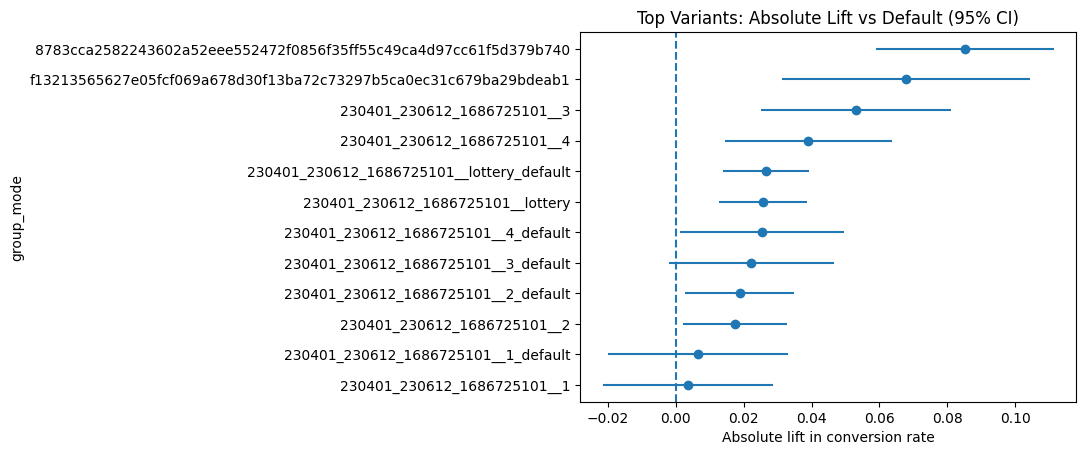

In [28]:
top_plot = tests.sort_values("abs_lift", ascending=False).head(12).copy()
top_plot = top_plot.sort_values("abs_lift")

x = np.asarray(top_plot["abs_lift"], dtype=float)
ci_low = np.asarray(top_plot["ci_low"], dtype=float)
ci_high = np.asarray(top_plot["ci_high"], dtype=float)

xerr_low = x - ci_low
xerr_high = ci_high - x

y = top_plot["group_mode"].astype(str).to_numpy()

plt.figure()
plt.errorbar(x, y, xerr=np.vstack([xerr_low, xerr_high]), fmt="o")
plt.axvline(0, linestyle="--")
plt.title("Top Variants: Absolute Lift vs Default (95% CI)")
plt.xlabel("Absolute lift in conversion rate")
plt.ylabel("group_mode")
plt.show()


## Guardrail Lens (Bounce Rate)

Even if a variant improves conversion, we avoid rollout if it worsens user experience.
We use bounce rate as a lightweight guardrail.

Below, we compare bounce rate for top lift variants vs default.


In [29]:
bounce_view = tests.sort_values("abs_lift", ascending=False).head(12).copy()
bounce_view["bounce_delta"] = bounce_view["bounce_treat"] - bounce_view["bounce_control"]

bounce_view[["group_mode", "n_treat", "abs_lift", "ci_low", "ci_high", "bounce_treat", "bounce_control", "bounce_delta", "p_adj_fdr"]].sort_values("bounce_delta")


,group_mode,n_treat,abs_lift,ci_low,ci_high,bounce_treat,bounce_control,bounce_delta,p_adj_fdr
0,8783cca2582243602a52eee552472f0856f35ff55c49ca...,635,0.085131,0.058878,0.111384,0.398425,0.619587,-0.221162,2.683020e-23
4,230401_230612_1686725101__lottery_default,1609,0.026517,0.013807,0.039227,0.457427,0.619587,-0.162160,1.457003e-06
5,230401_230612_1686725101__lottery,1527,0.025805,0.012821,0.038788,0.474132,0.619587,-0.145455,4.333481e-06
1,f13213565627e05fcf069a678d30f13ba72c73297b5ca0...,291,0.067825,0.031368,0.104282,0.481100,0.619587,-0.138488,1.962310e-07
3,230401_230612_1686725101__4,496,0.039100,0.014562,0.063638,0.487903,0.619587,-0.131684,6.510011e-05
6,230401_230612_1686725101__4_default,437,0.025361,0.001253,0.049469,0.503432,0.619587,-0.116155,1.509077e-02
7,230401_230612_1686725101__3_default,413,0.022219,-0.002064,0.046503,0.503632,0.619587,-0.115955,3.711993e-02
9,230401_230612_1686725101__2,968,0.017439,0.002072,0.032806,0.523760,0.619587,-0.095827,1.469235e-02
2,230401_230612_1686725101__3,436,0.053047,0.025027,0.081066,0.538991,0.619587,-0.080596,5.045047e-07
8,230401_230612_1686725101__2_default,886,0.018757,0.002545,0.034969,0.541761,0.619587,-0.077827,1.343095e-02


## Robustness Check (Sensitivity)

We re-run variant vs default comparisons under stricter session-quality filters:
- Filter A: sessions with `n_events >= 2`
- Filter B: sessions with `session_duration_sec >= 10` (if available)

We do NOT expect identical numbers, but we expect top variants to remain strong.


In [30]:
def run_variant_tests(sess_df, min_n=200):
    default_df = sess_df[sess_df["group_mode"] == "default"]
    n_c = default_df.shape[0]
    x_c = int(default_df["converted_hi"].sum())

    # keep stable variants in this subset
    counts = sess_df["group_mode"].value_counts()
    keep = counts[(counts >= min_n) | (counts.index == "default")].index.tolist()

    rows = []
    for g in keep:
        if g == "default":
            continue
        df_g = sess_df[sess_df["group_mode"] == g]
        n_t = df_g.shape[0]
        x_t = int(df_g["converted_hi"].sum())

        res = two_prop_test(x_t=x_t, n_t=n_t, x_c=x_c, n_c=n_c)
        rows.append({
            "group_mode": g,
            "n_treat": n_t,
            "abs_lift": res["abs_lift"],
            "ci_low": res["ci_low"],
            "ci_high": res["ci_high"],
            "p_value": res["p_value"],
        })

    out = pd.DataFrame(rows)
    out["p_adj_fdr"] = benjamini_hochberg(out["p_value"])
    out["sig_fdr_0.05"] = out["p_adj_fdr"] < 0.05
    return out.sort_values(["sig_fdr_0.05", "abs_lift"], ascending=[False, False]).reset_index(drop=True)

sens_all = run_variant_tests(session, min_n=MIN_N)
sens_e2 = run_variant_tests(session[session["n_events"] >= 2], min_n=MIN_N)

sens_d10 = None
if "session_duration_sec" in session.columns:
    sens_d10 = run_variant_tests(session[session["session_duration_sec"] >= 10], min_n=MIN_N)

sens_all.head(10), sens_e2.head(10), (sens_d10.head(10) if sens_d10 is not None else None)


(                                          group_mode  n_treat  abs_lift    ci_low   ci_high       p_value     p_adj_fdr  sig_fdr_0.05
 0  8783cca2582243602a52eee552472f0856f35ff55c49ca...      635  0.085131  0.058878  0.111384  2.235850e-24  2.683020e-23          True
 1  f13213565627e05fcf069a678d30f13ba72c73297b5ca0...      291  0.067825  0.031368  0.104282  3.270516e-08  1.962310e-07          True
 2                        230401_230612_1686725101__3      436  0.053047  0.025027  0.081066  1.261262e-07  5.045047e-07          True
 3                        230401_230612_1686725101__4      496  0.039100  0.014562  0.063638  3.255006e-05  6.510011e-05          True
 4          230401_230612_1686725101__lottery_default     1609  0.026517  0.013807  0.039227  4.856678e-07  1.457003e-06          True
 5                  230401_230612_1686725101__lottery     1527  0.025805  0.012821  0.038788  1.805617e-06  4.333481e-06          True
 6                230401_230612_1686725101__4_default  

In [31]:
TOPN = 8

top_all = sens_all.head(TOPN)[["group_mode", "abs_lift"]].rename(columns={"abs_lift": "lift_all"})
top_e2  = sens_e2.head(TOPN)[["group_mode", "abs_lift"]].rename(columns={"abs_lift": "lift_n_events>=2"})

merged = top_all.merge(top_e2, on="group_mode", how="outer")

if sens_d10 is not None:
    top_d10 = sens_d10.head(TOPN)[["group_mode", "abs_lift"]].rename(columns={"abs_lift": "lift_duration>=10s"})
    merged = merged.merge(top_d10, on="group_mode", how="outer")

merged.sort_values(by=["lift_all"], ascending=False)


,group_mode,lift_all,lift_n_events>=2,lift_duration>=10s
8,8783cca2582243602a52eee552472f0856f35ff55c49ca...,0.085131,0.099418,0.098042
9,f13213565627e05fcf069a678d30f13ba72c73297b5ca0...,0.067825,NaN,NaN
2,230401_230612_1686725101__3,0.053047,0.067522,NaN
4,230401_230612_1686725101__4,0.039100,0.050051,0.045778
7,230401_230612_1686725101__lottery_default,0.026517,0.017138,0.012706
6,230401_230612_1686725101__lottery,0.025805,0.014171,0.012011
5,230401_230612_1686725101__4_default,0.025361,0.014309,0.010237
3,230401_230612_1686725101__3_default,0.022219,0.015635,NaN
0,230401_230612_1686725101__2,NaN,NaN,0.010902
1,230401_230612_1686725101__2_default,NaN,0.016693,0.018104


🧾 Summary & Recommendation

Across multiple sensitivity analyses, several non-default UI variants demonstrate statistically significant and practically meaningful improvements over the default UI.

Key observations:

One variant (8783cca…) consistently shows the largest and most stable uplift:

+8–10 pp absolute lift in high-intent conversion

Substantial reduction in bounce rate

Robust to sample-quality filters

The relative ranking of top variants remains stable across stricter session filters, suggesting the effects are driven by genuine user engagement rather than noise.

Variants with small sample sizes fail to survive multiple-testing correction and are therefore not considered reliable candidates.

Recommendation:
Prioritize the top-performing variant(s) for a follow-up randomized A/B test or gradual rollout, while monitoring guardrail metrics such as bounce rate and session depth.